# Klasifikasi Kacamata dan Helm Menggunakan GLCM + HOG + LBP + KNN
Notebook ini mengimplementasikan klasifikasi menggunakan kombinasi ekstraksi fitur **GLCM** (tekstur), **HOG** (bentuk), dan **LBP** (pola lokal), kemudian diklasifikasikan menggunakan **KNN** dengan nilai K optimal.

In [2]:
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from skimage.feature import graycomatrix, graycoprops, hog, local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

IMG_SIZE = (128, 128)
CLASSES  = ['helm', 'kacamata']

def extract_features(image_path):
    """Mengekstrak fitur GLCM + HOG + LBP dari gambar."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # 1. Resize
    img_resized = cv2.resize(img, IMG_SIZE)

    # 2. CLAHE: Contrast Limited Adaptive Histogram Equalization
    #    Meningkatkan kontras lokal agar fitur lebih diskriminatif
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_enhanced = clahe.apply(img_resized)

    # 3. GLCM - Fitur Tekstur
    distances = [1, 3]
    angles    = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(img_enhanced, distances=distances, angles=angles,
                        levels=256, symmetric=True, normed=True)
    glcm_features = np.hstack([
        graycoprops(glcm, 'contrast').flatten(),
        graycoprops(glcm, 'correlation').flatten(),
        graycoprops(glcm, 'energy').flatten(),
        graycoprops(glcm, 'homogeneity').flatten(),
        graycoprops(glcm, 'ASM').flatten(),
        graycoprops(glcm, 'dissimilarity').flatten(),
    ])  # 48 dimensi

    # 4. HOG - Fitur Bentuk/Gradien
    hog_features = hog(
        img_enhanced, orientations=8,
        pixels_per_cell=(16, 16), cells_per_block=(2, 2),
        visualize=False
    )  # 1568 dimensi

    # 5. LBP - Local Binary Pattern (Pola Tekstur Lokal)
    #    Sangat efektif membedakan pola permukaan kacamata vs helm
    radius   = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img_enhanced, n_points, radius, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2,
                                range=(0, n_points + 2), density=True)
    # 26 dimensi

    return np.hstack([glcm_features, hog_features, lbp_hist])

def load_dataset(base_dir):
    features_list, labels_list = [], []
    for class_idx, class_name in enumerate(CLASSES):
        class_dir = os.path.join(base_dir, class_name)
        if not os.path.exists(class_dir):
            print(f'  Direktori tidak ditemukan: {class_dir}')
            continue
        files = glob.glob(os.path.join(class_dir, '*.*'))
        print(f"  Kelas '{class_name}': {len(files)} gambar")
        for img_path in tqdm(files, desc=f'Ekstraksi {class_name}'):
            feat = extract_features(img_path)
            if feat is not None:
                features_list.append(feat)
                labels_list.append(class_idx)
    return np.array(features_list), np.array(labels_list)

print('Memuat dataset training (GLCM + HOG + LBP)...')
X_raw, y_raw = load_dataset('dataset/train')
n_helm      = int(np.sum(y_raw == 0))
n_kacamata  = int(np.sum(y_raw == 1))
print(f'\nSelesai! Total: {X_raw.shape[0]} sampel | helm={n_helm} | kacamata={n_kacamata}')
print(f'Dimensi fitur per gambar: {X_raw.shape[1]} (GLCM=48, HOG=1568, LBP=26)')


Memuat dataset training (GLCM + HOG + LBP)...
  Kelas 'helm': 1436 gambar


Ekstraksi helm:   0%|          | 0/1436 [00:00<?, ?it/s]

  Kelas 'kacamata': 754 gambar


Ekstraksi kacamata:   0%|          | 0/754 [00:00<?, ?it/s]


Selesai! Total: 2190 sampel | helm=1436 | kacamata=754
Dimensi fitur per gambar: 1642 (GLCM=48, HOG=1568, LBP=26)


## Mencari Nilai K Optimal
Gunakan `weights='distance'` agar tetangga yang lebih dekat mendapat bobot lebih besar — ini mengurangi pengaruh kelas mayor (helm) yang jumlahnya lebih banyak.

Data Training: 1752 | Data Validasi: 438

Mencari nilai K optimal (dengan distance-weighting)...
  k =  1  ->  Akurasi Validasi: 94.29%
  k =  3  ->  Akurasi Validasi: 92.47%
  k =  5  ->  Akurasi Validasi: 92.92%
  k =  7  ->  Akurasi Validasi: 90.64%
  k =  9  ->  Akurasi Validasi: 89.95%
  k = 11  ->  Akurasi Validasi: 89.27%
  k = 13  ->  Akurasi Validasi: 89.04%
  k = 15  ->  Akurasi Validasi: 87.21%


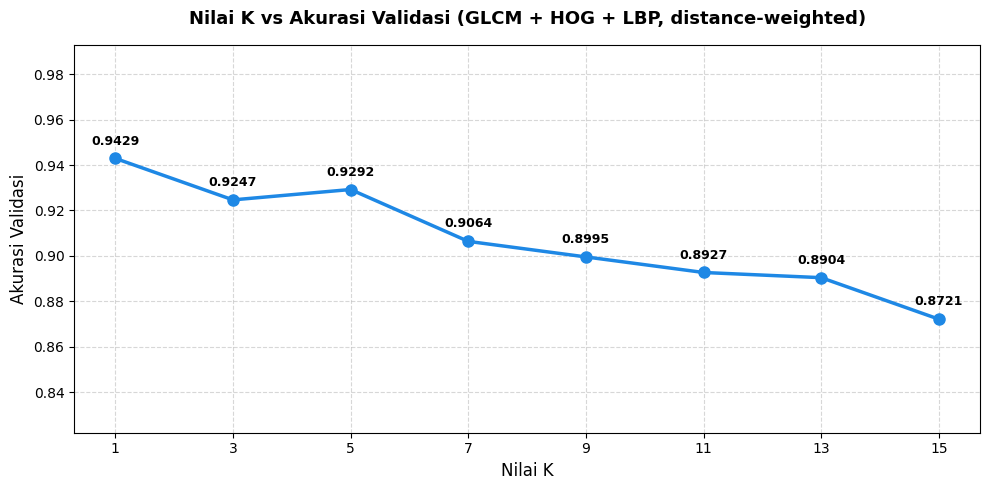


K optimal: 1 (Akurasi Validasi: 94.29%)


In [3]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
scaler_val   = StandardScaler()
X_tr_scaled  = scaler_val.fit_transform(X_tr)
X_val_scaled = scaler_val.transform(X_val)

print(f'Data Training: {X_tr_scaled.shape[0]} | Data Validasi: {X_val_scaled.shape[0]}')
print('\nMencari nilai K optimal (dengan distance-weighting)...')

k_values       = list(range(1, 16, 2))
val_accuracies = []

for k in k_values:
    # weights='distance': tetangga lebih dekat = bobot lebih besar
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    knn.fit(X_tr_scaled, y_tr)
    acc = accuracy_score(y_val, knn.predict(X_val_scaled))
    val_accuracies.append(acc)
    print(f'  k = {k:2d}  ->  Akurasi Validasi: {acc*100:.2f}%')

# Visualisasi
plt.figure(figsize=(10, 5))
plt.plot(k_values, val_accuracies, marker='o', linestyle='-',
         color='#1e88e5', linewidth=2.5, markersize=8)
plt.title('Nilai K vs Akurasi Validasi (GLCM + HOG + LBP, distance-weighted)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nilai K', fontsize=12)
plt.ylabel('Akurasi Validasi', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(k_values)
for i, acc in enumerate(val_accuracies):
    plt.annotate(f'{acc:.4f}', (k_values[i], acc),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, fontweight='bold')
plt.ylim(min(val_accuracies) - 0.05, max(val_accuracies) + 0.05)
plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(val_accuracies))]
print(f'\nK optimal: {best_k} (Akurasi Validasi: {max(val_accuracies)*100:.2f}%)')


## Pelatihan Model Final
Latih pada **seluruh data training** dengan K terbaik dan `weights='distance'`.

In [4]:
scaler_final  = StandardScaler()
X_train_final = scaler_final.fit_transform(X_raw)

knn_final = KNeighborsClassifier(n_neighbors=best_k,
                                  weights='distance',
                                  metric='euclidean')
knn_final.fit(X_train_final, y_raw)
print(f'Model KNN Final (k={best_k}, weights=distance, fitur=GLCM+HOG+LBP) siap!')


Model KNN Final (k=1, weights=distance, fitur=GLCM+HOG+LBP) siap!


## Demo Klasifikasi: Visualisasi Tahapan Preprocessing
Menampilkan setiap tahapan preprocessing pada contoh gambar.

=== DEMO: Contoh dari Dataset Test ===
Contoh Helm:


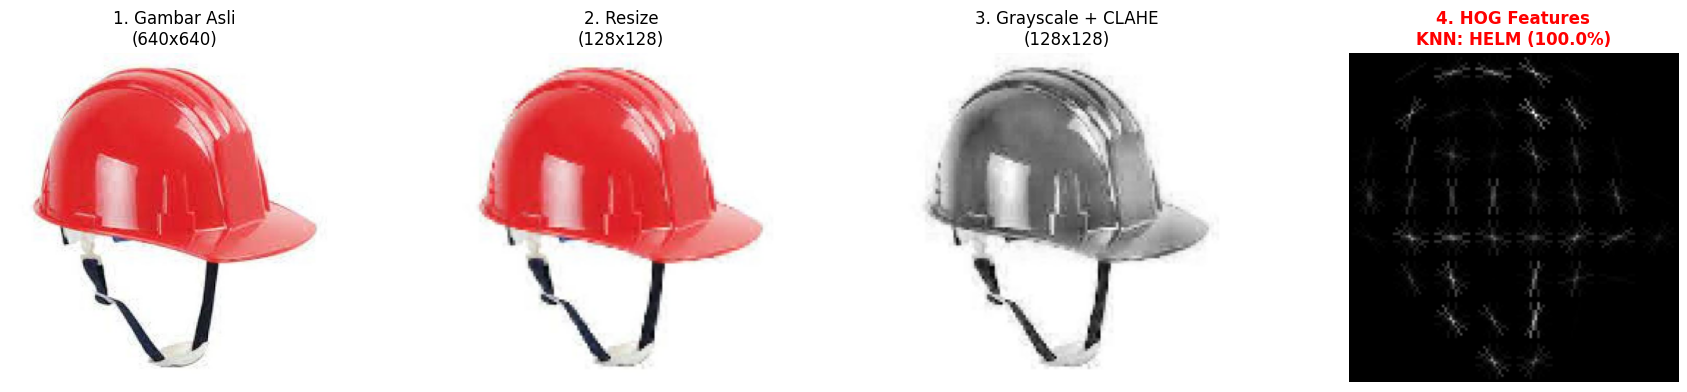

Contoh Kacamata:


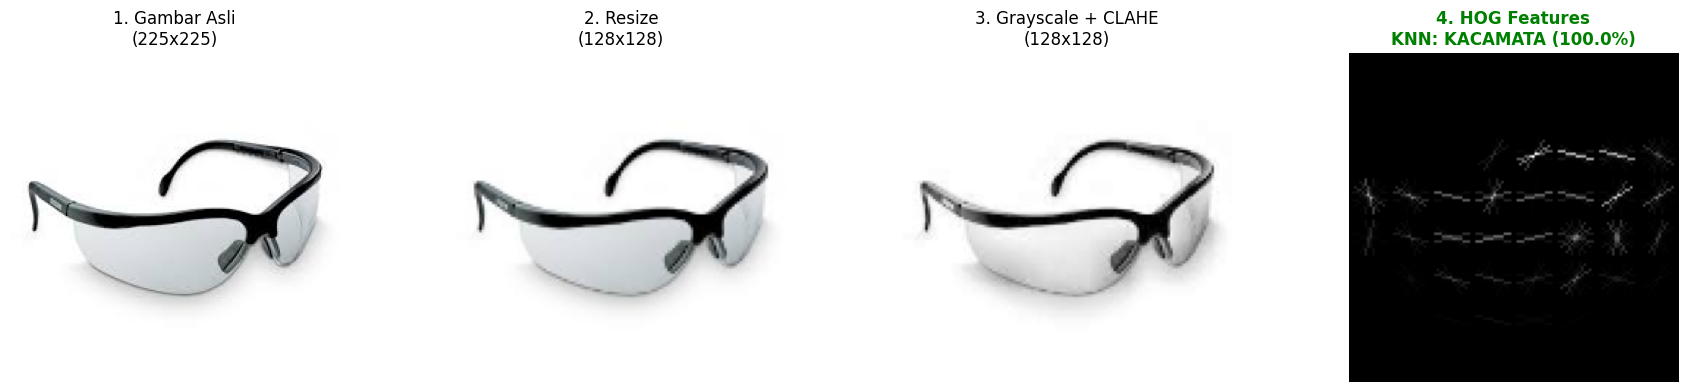

In [5]:
def classify_and_visualize(image_path, model, scaler_model):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f'Gambar tidak ditemukan: {image_path}')
        return

    h_orig, w_orig = img_bgr.shape[:2]
    img_gray_orig  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_resized    = cv2.resize(img_gray_orig, IMG_SIZE)
    clahe_obj      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced   = clahe_obj.apply(img_resized)

    _, hog_image = hog(
        img_enhanced, orientations=8, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), visualize=True
    )

    feat      = extract_features(image_path)
    feat_sc   = scaler_model.transform([feat])
    pred_id   = model.predict(feat_sc)[0]
    proba     = model.predict_proba(feat_sc)[0]
    label     = CLASSES[pred_id]
    confidence = proba[pred_id] * 100

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'1. Gambar Asli\n({w_orig}x{h_orig})')
    axes[1].imshow(cv2.cvtColor(cv2.resize(img_bgr, IMG_SIZE), cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'2. Resize\n({IMG_SIZE[0]}x{IMG_SIZE[1]})')
    axes[2].imshow(img_enhanced, cmap='gray')
    axes[2].set_title(f'3. Grayscale + CLAHE\n({IMG_SIZE[0]}x{IMG_SIZE[1]})')
    axes[3].imshow(hog_image, cmap='gray')
    color_title = 'green' if pred_id == 1 else 'red'
    axes[3].set_title(f'4. HOG Features\nKNN: {label.upper()} ({confidence:.1f}%)',
                      color=color_title, fontweight='bold')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('=== DEMO: Contoh dari Dataset Test ===')
helm_samples = glob.glob('dataset/test/helm/*.*')
if helm_samples:
    print('Contoh Helm:')
    classify_and_visualize(helm_samples[0], knn_final, scaler_final)

kaca_samples = glob.glob('dataset/test/kacamata/*.*')
if kaca_samples:
    print('Contoh Kacamata:')
    classify_and_visualize(kaca_samples[0], knn_final, scaler_final)


## Evaluasi Model pada Dataset Test

Memuat dataset test...
  Kelas 'helm': 33 gambar


Ekstraksi helm:   0%|          | 0/33 [00:00<?, ?it/s]

  Kelas 'kacamata': 43 gambar


Ekstraksi kacamata:   0%|          | 0/43 [00:00<?, ?it/s]

Selesai! Jumlah sampel test: 76

Akurasi KNN + GLCM + HOG + LBP pada Test Set: 84.21%

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Helm       0.80      0.85      0.82        33
    Kacamata       0.88      0.84      0.86        43

    accuracy                           0.84        76
   macro avg       0.84      0.84      0.84        76
weighted avg       0.84      0.84      0.84        76



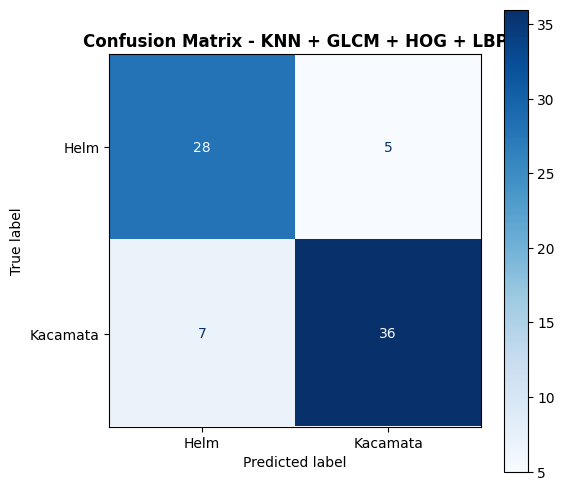

In [6]:
print('Memuat dataset test...')
X_test_raw, y_test = load_dataset('dataset/test')
print(f'Selesai! Jumlah sampel test: {X_test_raw.shape[0]}')

X_test_scaled = scaler_final.transform(X_test_raw)
y_pred        = knn_final.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)
labels_name   = ['Helm', 'Kacamata']
print(f'\nAkurasi KNN + GLCM + HOG + LBP pada Test Set: {test_accuracy * 100:.2f}%')
print('\n--- CLASSIFICATION REPORT ---')
print(classification_report(y_test, y_pred, target_names=labels_name, zero_division=0))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_name)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - KNN + GLCM + HOG + LBP', fontsize=12, fontweight='bold')
plt.show()


## 🧪 Pengujian 10 Gambar (5 Helm, 5 Kacamata) dari Test Set
Mengambil masing-masing 5 gambar helm dan 5 kacamata dari dataset test yang digunakan pada confusion matrix, lalu menampilkan hasil prediksinya.

=== Pengujian 10 Gambar Acak (5 Helm, 5 Kacamata) dari Test Set ===


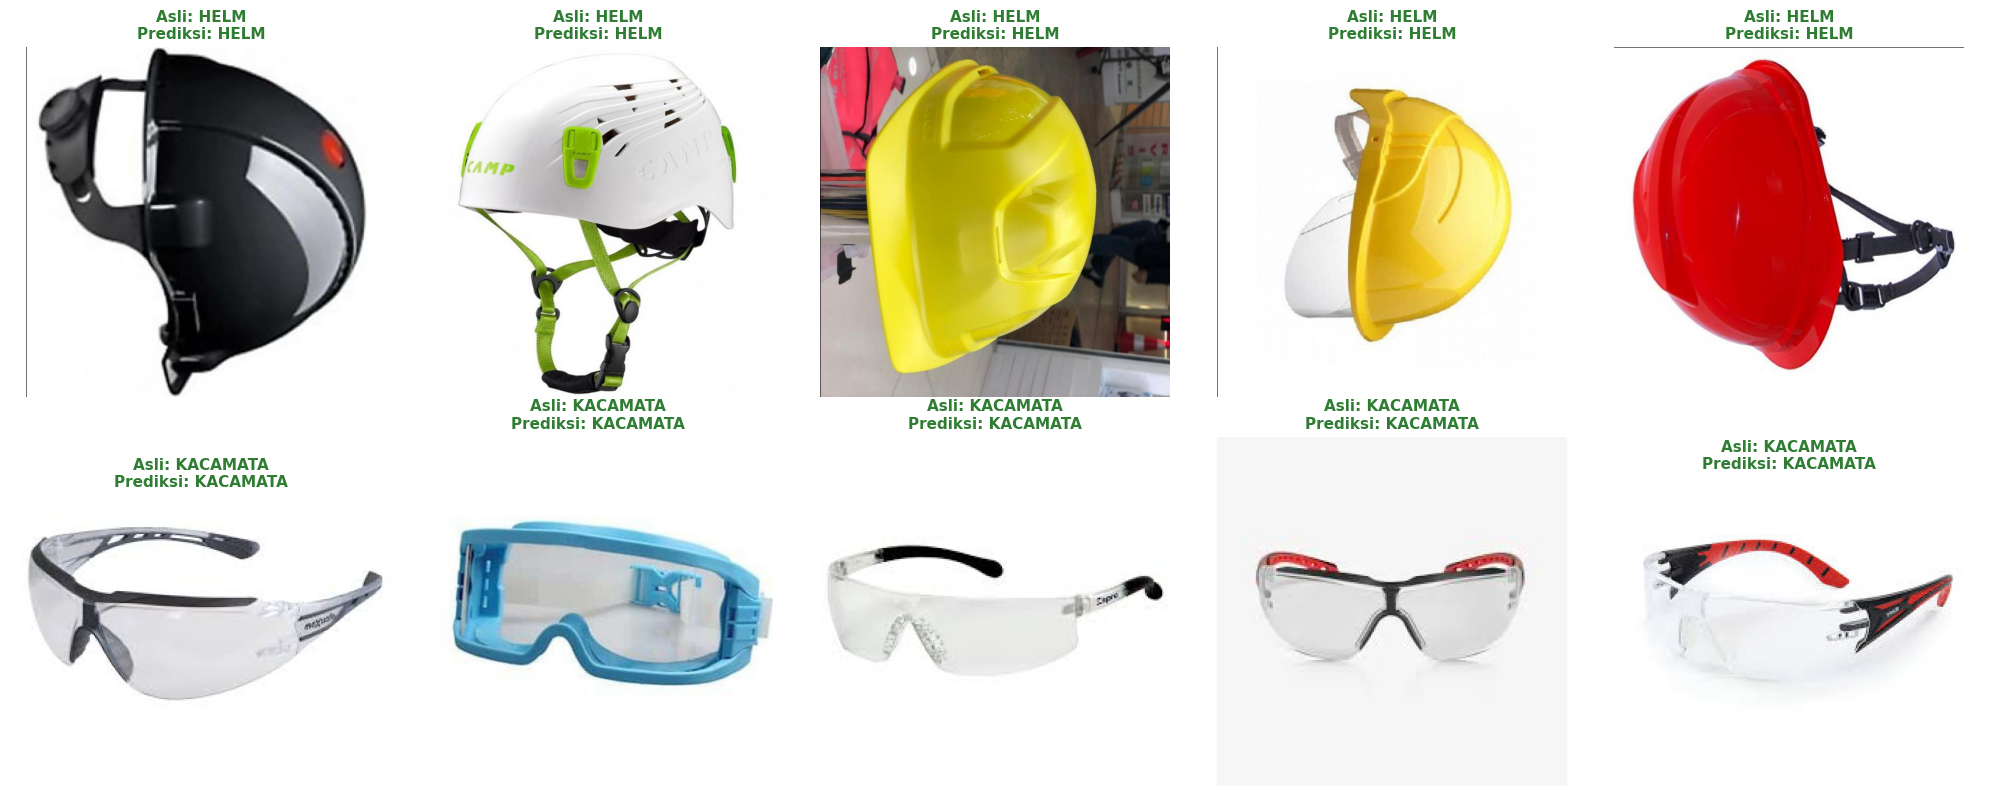

In [25]:
import glob
import os
import random
import matplotlib.pyplot as plt
import cv2

print('=== Pengujian 10 Gambar Acak (5 Helm, 5 Kacamata) dari Test Set ===')

# Mengambil 5 gambar helm dan 5 gambar kacamata secara acak
helm_all = glob.glob('dataset/test/helm/*.*')
kacamata_all = glob.glob('dataset/test/kacamata/*.*')

helm_samples = random.sample(helm_all, min(5, len(helm_all)))
kacamata_samples = random.sample(kacamata_all, min(5, len(kacamata_all)))

test_images = helm_samples + kacamata_samples

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, img_path in enumerate(test_images):
    if not os.path.exists(img_path):
        continue
        
    features = extract_features(img_path)
    if features is None:
        continue
        
    features_scaled = scaler_final.transform([features])
    prediction      = knn_final.predict(features_scaled)[0]
    probabilities   = knn_final.predict_proba(features_scaled)[0]
    predicted_class = CLASSES[prediction]
    #confidence      = probabilities[prediction] * 100
    
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    true_label = 'helm' if 'helm' in img_path.lower() else 'kacamata'
    color = '#2e7d32' if predicted_class.lower() == true_label else '#c62828'
    
    axes[i].imshow(img_rgb)
    axes[i].set_title(
        f'Asli: {true_label.upper()}\nPrediksi: {predicted_class.upper()}',
        fontsize=11, fontweight='bold', color=color
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()
